# 03 Exploratory Data Analysis

This notebook explores crash patterns across driver involvement, casualty severity, helmet/restraint use, age groups, speeding, and drink driving.

The original code cells are preserved. Only Markdown section titles and explanations have been added for GitHub readability.


## 1. Crash Severity Distribution Over Time

This section visualises crash severity patterns by crash year using the driver involvement dataset.


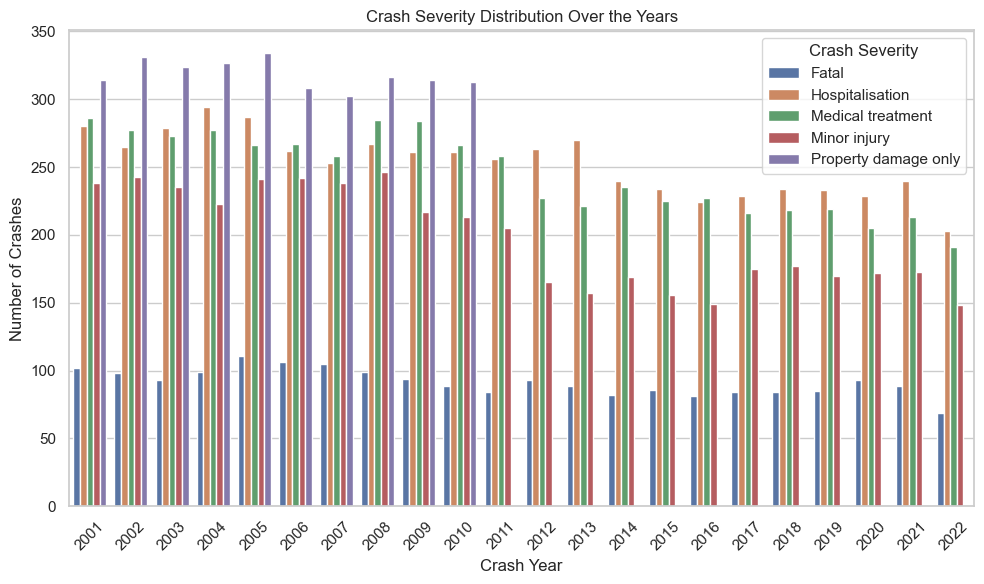

In [ ]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=df_DI, x='Crash_Year', hue='Crash_Severity')
plt.title('Crash Severity Distribution Over the Years')
plt.xlabel('Crash Year')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=45)
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()


## 2. Crash Severity by Male Driver Involvement

This chart compares crash severity between crashes involving male drivers and those not involving male drivers.


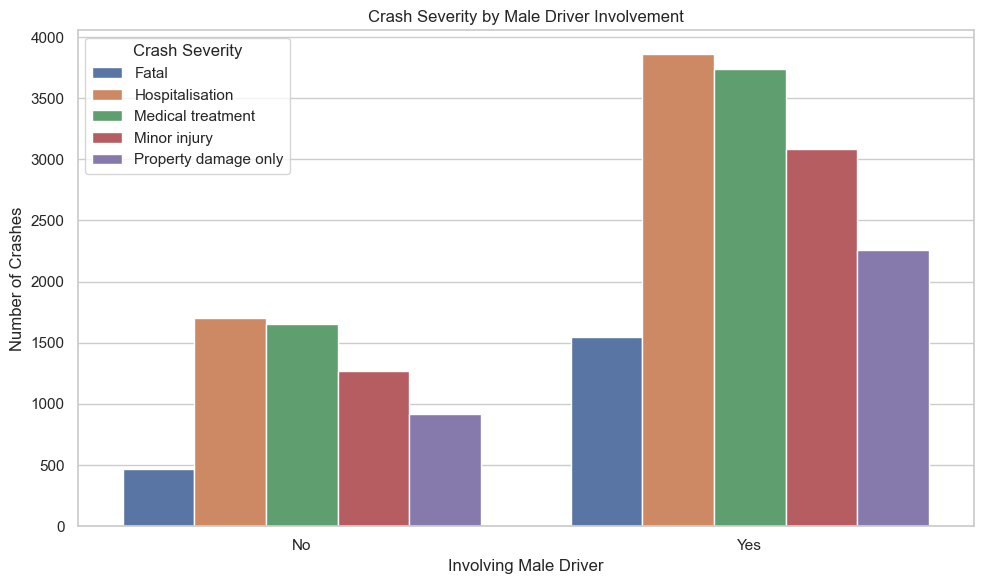

In [32]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_DI, x='Involving_Male_Driver', hue='Crash_Severity')
plt.title('Crash Severity by Male Driver Involvement')
plt.xlabel('Involving Male Driver')
plt.ylabel('Number of Crashes')
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()

## 3. Casualty Count Feature Inspection

This section selects casualty count columns for inspection, including hospitalised, medically treated, and total casualty counts.


In [ ]:
df_DI_afs=df_DI[["Count_Casualty_Hospitalised","Count_Casualty_MedicallyTreated", "Count_Casualty_All"]]

## 4. Helmet / Restraint Dataset Cleaning

This section performs basic cleaning on the helmet/restraint use dataset, including missing value removal and duplicate checking.


Number of duplicate rows: 0
Casualty_Count: 0.356
Casualty_AgeGroup: 0.242
Crash_PoliceRegion: 0.233
Casualty_Restraint_Helmet_Use: 0.106
Casualty_Gender: 0.040
Casualty_Road_User_Type: 0.023


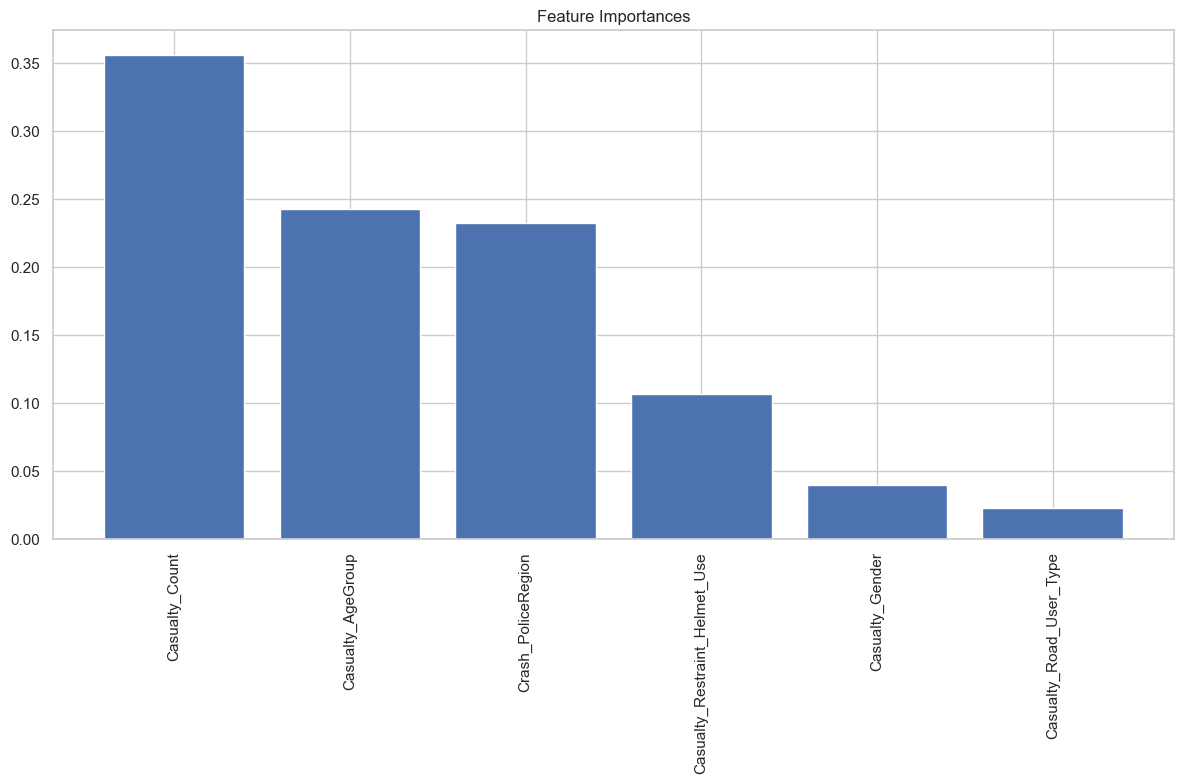

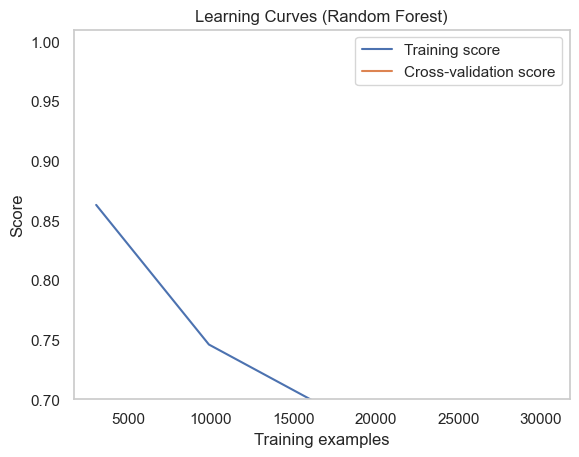

In [33]:
df=df_HU
#data clean
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])
# crash year is the first one, need check
data = df.drop(['Crash_Year'],axis=1)
label_encoders = {}
for column in data.columns:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le
X = data.drop('Casualty_Severity', axis=1)  # based on the Casualty_Severity
y = data['Casualty_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")#print
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
#learning Curves check(after delete crash_year columnns)
title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()

## 5. Casualty Severity by Helmet / Restraint Use

This chart analyses the relationship between helmet/restraint use and casualty severity.


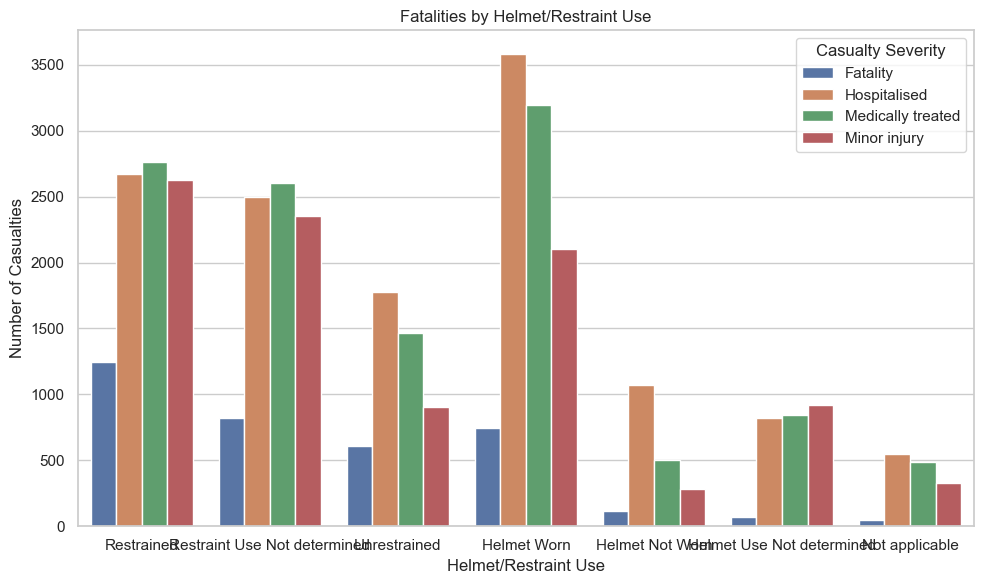

In [34]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_HU, x='Casualty_Restraint_Helmet_Use', hue='Casualty_Severity')
plt.title('Fatalities by Helmet/Restraint Use')
plt.xlabel('Helmet/Restraint Use')
plt.ylabel('Number of Casualties')
plt.legend(title='Casualty Severity')
plt.tight_layout()
plt.show()

## 6. Road Casualty Dataset Cleaning

This section performs basic cleaning on the road casualties dataset before casualty severity analysis.


Number of duplicate rows: 0
Casualty_Count: 0.372
Casualty_AgeGroup: 0.237
Crash_Police_Region: 0.231
Casualty_RoadUserType: 0.127
Casualty_Gender: 0.033


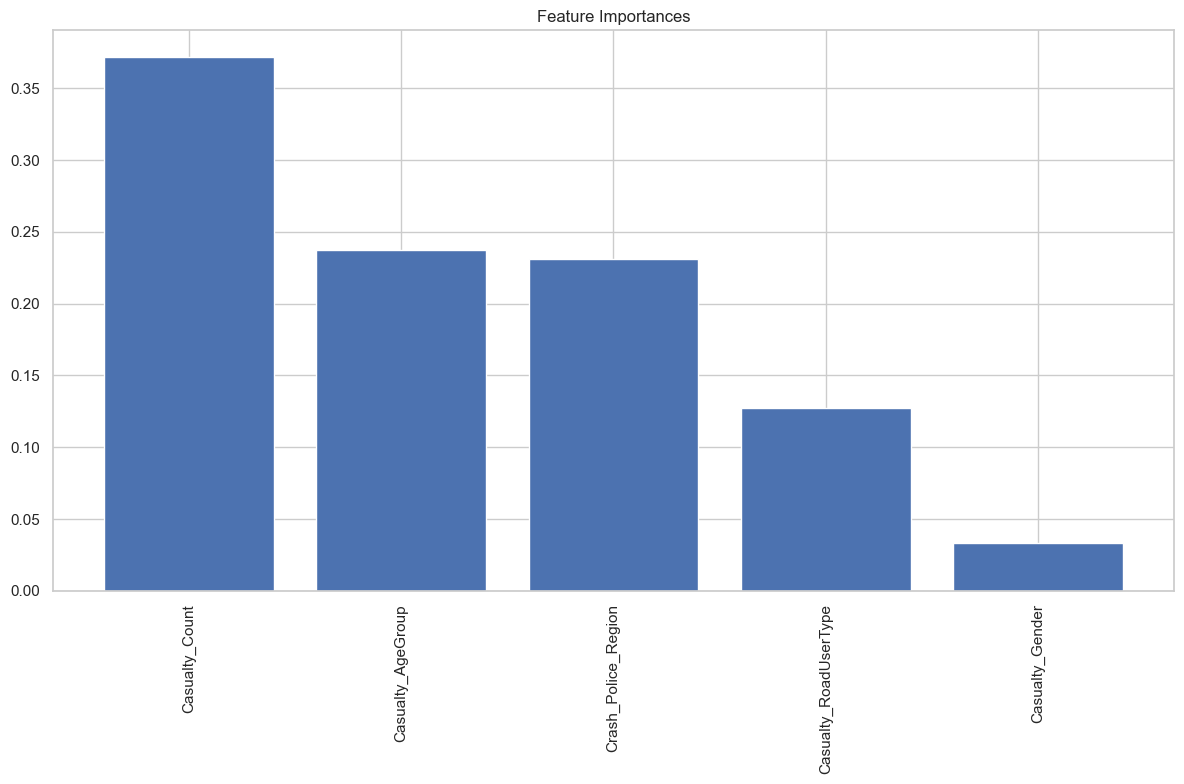

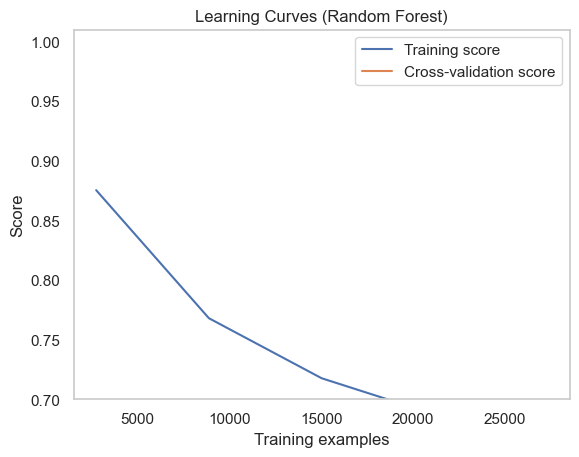

In [35]:
df=df_RC
#data clean
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])
# drop Crash_Year
data = df.drop(['Crash_Year'],axis=1)
#data processing(encoding all)
label_encoders = {}
for column in data.columns:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le
X = data.drop('Casualty_Severity', axis=1)  # assume Casualty_Severity
y = data['Casualty_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]#print
for index in sorted_indices:
    print(f"{features[index]}: {importances[index]:.3f}")
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()
#use learning Curves check(after delete crash year)
title = "Learning Curves (Random Forest)"
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
plot_learning_curve(model, title, X, y, ylim=(0.7, 1.01), cv=cv, n_jobs=4)
plt.show()
df_RC=data

## 7. Casualty Severity and Age Group Analysis

This section explores casualty severity distribution and how severity varies across casualty age groups.


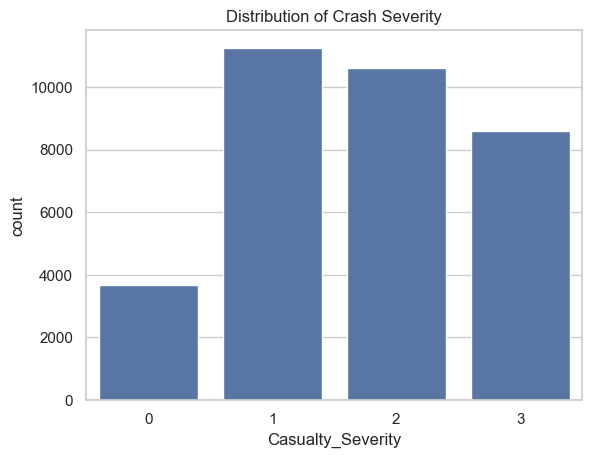

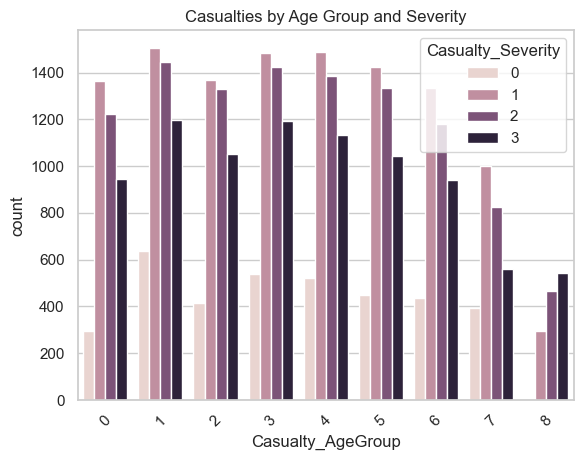

In [36]:
sns.countplot(data=df_RC, x='Casualty_Severity')
plt.title('Distribution of Crash Severity')
plt.show()
sns.countplot(data=df_RC, x='Casualty_AgeGroup', hue='Casualty_Severity')
plt.title('Casualties by Age Group and Severity')
plt.xticks(rotation=45)
plt.show()
numeric_df = df_RC.select_dtypes(include=['float64', 'int64'])


## 8. Crash Severity by Speeding Involvement

This chart analyses the relationship between speeding involvement and crash severity.


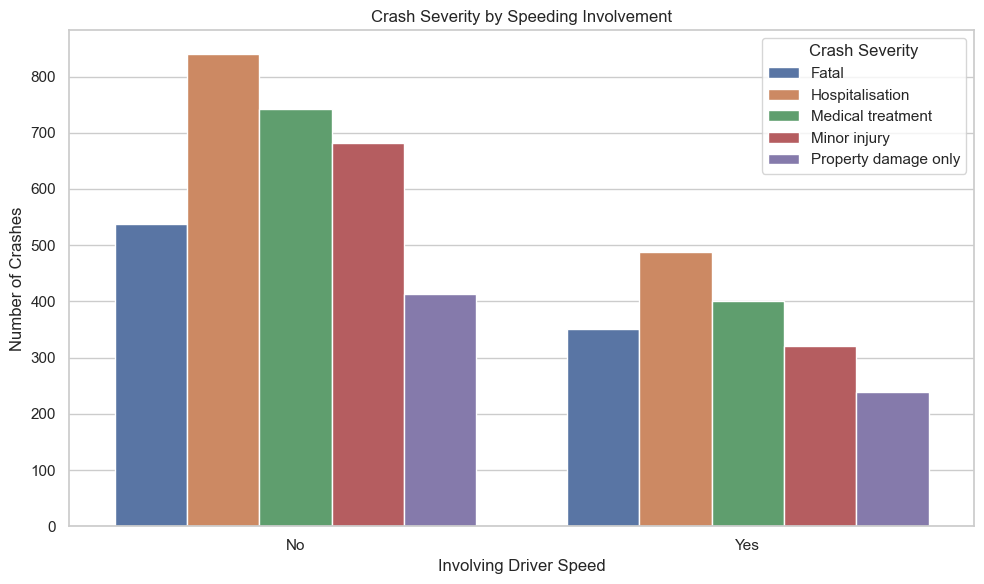

In [37]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_FIRC, x='Involving_Driver_Speed', hue='Crash_Severity')
plt.title('Crash Severity by Speeding Involvement')
plt.xlabel('Involving Driver Speed')
plt.ylabel('Number of Crashes')
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()


## 9. Crash Severity by Drink Driving Involvement

This chart analyses the relationship between drink driving involvement and crash severity.


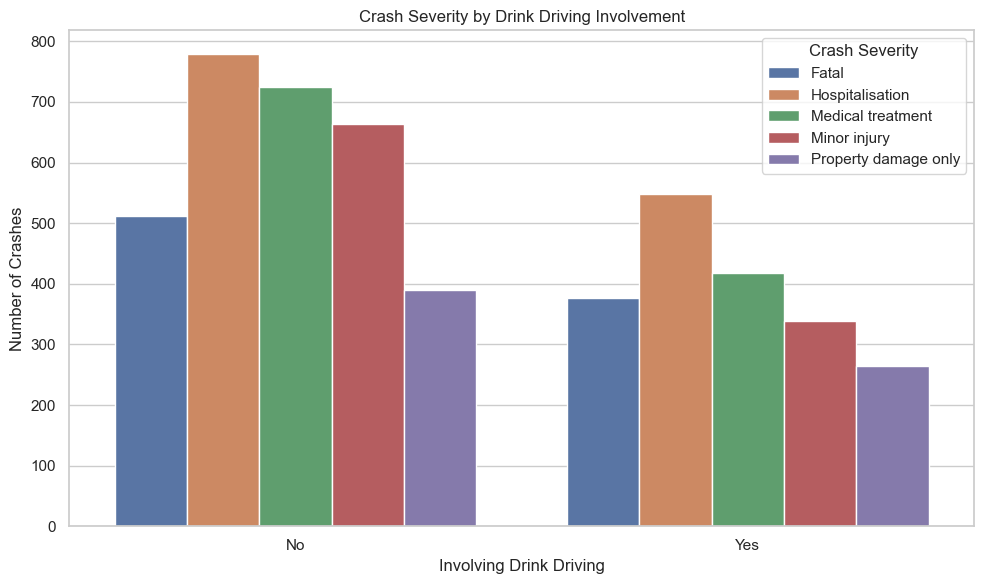

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_FIRC, x='Involving_Drink_Driving', hue='Crash_Severity')
plt.title('Crash Severity by Drink Driving Involvement')
plt.xlabel('Involving Drink Driving')
plt.ylabel('Number of Crashes')
plt.legend(title='Crash Severity')
plt.tight_layout()
plt.show()

## 10. Road Crash Factor Dataset Cleaning

This section performs basic cleaning on the road crash factor dataset after the speeding and drink driving visualisations.


Number of duplicate rows: 0
Count_Hospitalised: 0.268
Count_Fatality: 0.213
Count_Medically_Treated: 0.190
Count_All_Casualties: 0.156
Count_Minor_Injury: 0.110
Count_Crashes: 0.028
Crash_Year: 0.017
Involving_Defective_Vehicle: 0.005
Crash_Police_Region: 0.003
Involving_Fatigued_Driver: 0.003
Involving_Drink_Driving: 0.003
Involving_Driver_Speed: 0.003


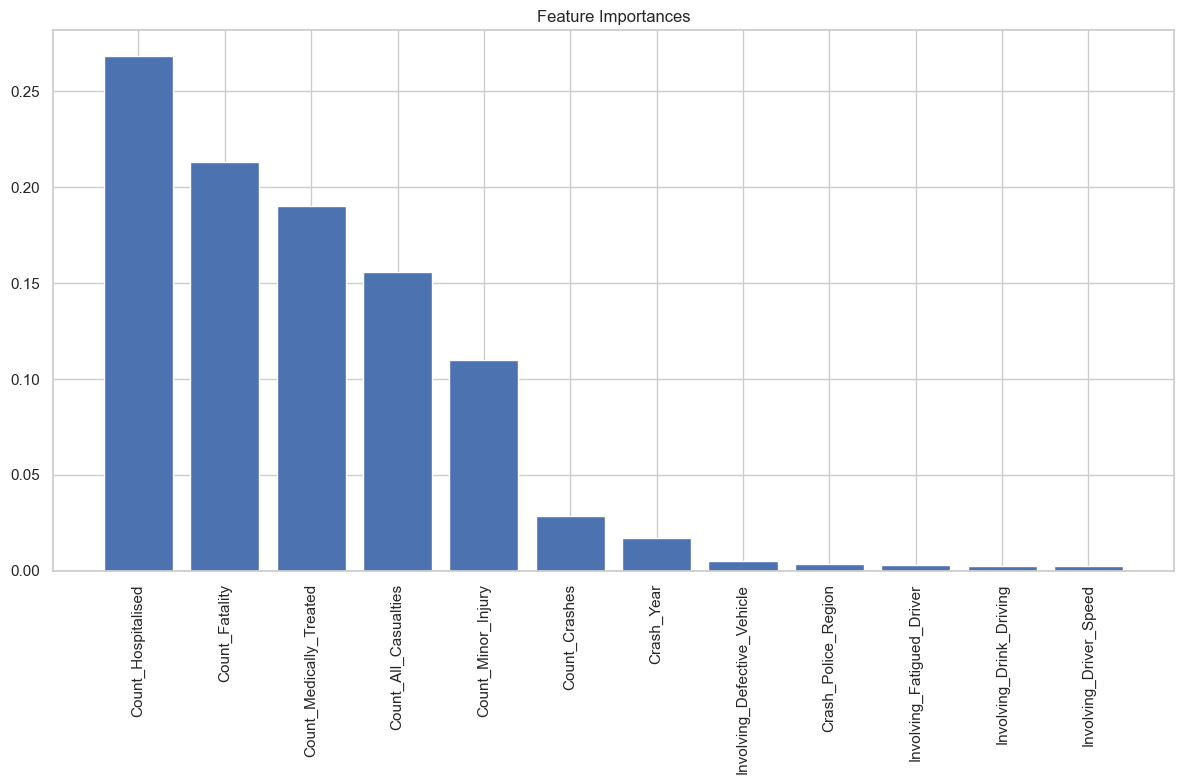

In [39]:
df=df_FIRC
#Data clean
df.dropna(inplace=True)
duplicates = df.duplicated()
print("Number of duplicate rows:", duplicates.sum())
if duplicates.sum() > 0:
    print(df[duplicates])

data = df

#data processing 
# all encode
label_encoders = {}
for column in data.columns:
    if data[column].dtype == object:
        le = LabelEncoder()
        data[column] = le.fit_transform(data[column])
        label_encoders[column] = le
X = data.drop('Crash_Severity', axis=1)  # assume Crash_severity
y = data['Crash_Severity']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
importances = model.feature_importances_
features = X.columns
sorted_indices = importances.argsort()[::-1]
for index in sorted_indices:#print
    print(f"{features[index]}: {importances[index]:.3f}")
plt.figure(figsize=(12, 8))
plt.title('Feature Importances')
plt.bar(range(X.shape[1]), importances[sorted_indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

## Summary

This EDA notebook provides visual evidence for several important crash-related factors, including driver gender involvement, casualty age group, helmet/restraint use, speeding, and drink driving.

These insights support later modelling and high-risk crash analysis.
